In [2]:
import albumentations as A
from PIL import Image
import requests
import matplotlib.pyplot as plt


SIZE = 224


def plot_image(original, transformed, figsize=(5, 2.5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # оригинал
    ax1.imshow(original, cmap='gray')
    ax1.set_title('original')
    ax1.axis('off')

    # аугментации
    ax2.imshow(transformed, cmap='gray')
    ax2.set_title('transformed')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

url = "https://raw.githubusercontent.com/jigsawpieces/dog-api-images/main/corgi/14917192_10154550690893449_81787730512372227_o.jpg"
response = requests.get(url, stream=True)

with open("data/corgi.jpg", "wb") as f:
    f.write(response.content)

img = Image.open("data/corgi.jpg")

transforms = A.Compose(
    [
        A.Resize(height=SIZE, width=SIZE, p=1.0),
        A.Affine(scale=(0.8, 1.2),
                 rotate=(-15, 15),
                 translate_percent=(-0.1, 0.1),
                 shear=(-10, 10),
                 fill=0,
                 p=1),
        A.MotionBlur(blur_limit=(3, 10), p=1),
    ],
    seed=4,
)

plot_image(img, transforms(image=img)["image"]) 

d:\Projects\praktikum\.venv\Lib\site-packages\albumentations\augmentations\blur\functional.py:232: UserWarning: blur_limit: Non-zero kernel sizes must be odd. Range (3, 10) automatically adjusted to (3, 11).
  result = _ensure_odd_values(result, info.field_name)


TypeError: image must be numpy array type

In [5]:
import requests
import librosa


url = "https://raw.githubusercontent.com/librosa/data/main/audio/Hungarian_Dance_number_5_-_Allegro_in_F_sharp_minor_(string_orchestra).hq.ogg"
response = requests.get(url, stream=True)

with open("data/music/Hungarian_Dance_number_5.ogg", "wb") as f:
    f.write(response.content)

# загрузка аудиофайла
audio_path = 'data/music/Hungarian_Dance_number_5.ogg'

# метод возвразает загруженный сигнал и расчетный sample rate

signal, sample_rate = librosa.load(audio_path, sr=None)

print(f"Частота дискретизации: {sample_rate} Гц")
print(f"Количество сэмплов: {len(signal)}")
print(f"Длительность: {len(signal)/sample_rate:.2f} секунд") 

Частота дискретизации: 44100 Гц
Количество сэмплов: 2021760
Длительность: 45.84 секунд


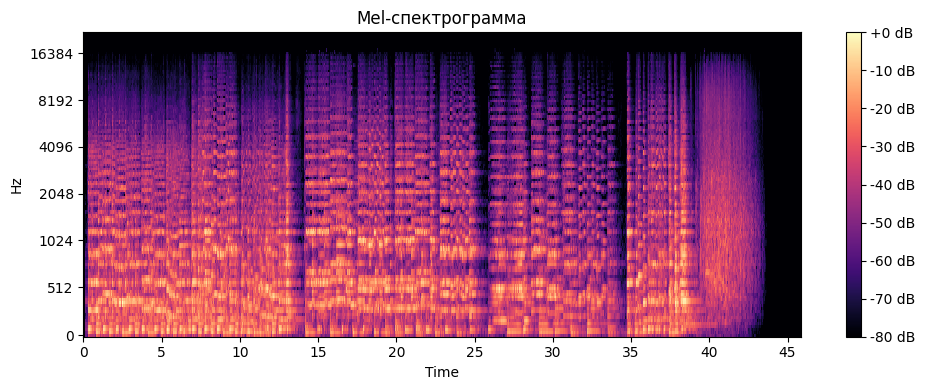

In [7]:
import numpy as np

# Параметры для спектрограммы
n_fft = 2048  # размер окна для FFT

hop_length = 512  # шаг между окнами
n_mels = 128  # количество Mel-фильтров
  
# Вычисление Mel-спектрограммы
mel_spec = librosa.feature.melspectrogram(y=signal, sr=sample_rate,
                                         n_fft=n_fft,
                                         hop_length=hop_length,
                                         n_mels=n_mels)

# Преобразование в децибелы
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

# Визуализация
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spec_db, sr=sample_rate,
                        hop_length=hop_length,
                        x_axis='time', y_axis='mel')

plt.colorbar(format='%+2.0f dB')
plt.title('Mel-спектрограмма')
plt.tight_layout()
plt.show() 

In [1]:
import os

from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm

import torchvision.transforms as T


class FaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # считываем пути до фото
        self.image_paths = [os.path.join(root_dir, f) for f in os.listdir(root_dir)
                          if f.endswith(('.jpg', '.PNG'))]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        # применяем трансформацию
        if self.transform:
            image = self.transform(image)

        return image, img_path


model_name = 'tf_efficientnet_b0'
cfg = timm.get_pretrained_cfg(model_name)

# формируем трансформации для фото
transform = T.Compose([
    T.Resize(cfg.input_size[1:]),
    T.ToTensor(),
    T.Normalize(mean=cfg.mean,
                std=cfg.std)
])

  
# Создаём DataLoader для проверенных и новых изображений
db_dataset = FaceDataset('data/faces/db', transform=transform)
new_dataset = FaceDataset('data/faces/new', transform=transform)

db_loader = DataLoader(db_dataset, batch_size=2, num_workers=2)
new_loader = DataLoader(new_dataset, batch_size=2, num_workers=2) 

d:\Projects\praktikum\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm
import torch.nn.functional as F
import torchvision.transforms as T


class FaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [os.path.join(root_dir, f) for f in os.listdir(root_dir)
                          if f.endswith(('.jpg', '.PNG'))]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, img_path


model_name = 'tf_efficientnet_b0'
cfg = timm.get_pretrained_cfg(model_name)

transform = T.Compose([
    T.ToTensor(),
    T.Resize(cfg.input_size[1:]),
    T.Normalize(mean=cfg.mean,
                std=cfg.std)
])

db_dataset = FaceDataset('data/faces/db', transform=transform)
new_dataset = FaceDataset('data/faces/new', transform=transform)

db_loader = DataLoader(db_dataset, batch_size=2, num_workers=0)
new_loader = DataLoader(new_dataset, batch_size=2, num_workers=0)


def get_embeddings(loader, model):
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    
    embeddings = []
    paths = []
    with torch.no_grad():
        # итерируемся по батчам
        for images, batch_paths in loader:
            images = images.to(device)
            features = model(images)

            # используем пуллинг для агрегации и конкатенируем
            features = torch.cat([F.avg_pool2d(x, (x.size(-2), x.size(-1))) for x in features], dim=1).squeeze((-1, -2))

            embeddings.append(features.cpu())
            paths.extend(batch_paths)
            images = images.to("cpu")

    model.to("cpu")
    return torch.cat(embeddings, dim=0), paths


model = timm.create_model(model_name, 
                          pretrained=True, 
                          features_only=True, 
                          out_indices=[3,4])
model.eval()

# Получаем эмбеддинги для проверенных и новых изображений
db_embeddings, db_paths = get_embeddings(db_loader, model)
new_embeddings, new_paths = get_embeddings(new_loader, model)

# Опционально сохраним для переиспользования
torch.save(db_embeddings, f="data/faces/db_embeddings.pt")
torch.save(new_embeddings, f="data/faces/new_embeddings.pt")

file_path = 'data/faces/new_paths'
np.save(file_path, np.array(new_paths))

print(new_embeddings.shape) 

Unexpected keys (bn2.bias, bn2.num_batches_tracked, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


torch.Size([9, 432])


C:\Users\Олег\AppData\Local\Temp\ipykernel_8576\3786329188.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  db_embeddings = torch.load("data/faces/db_embeddings.pt")
C:\U

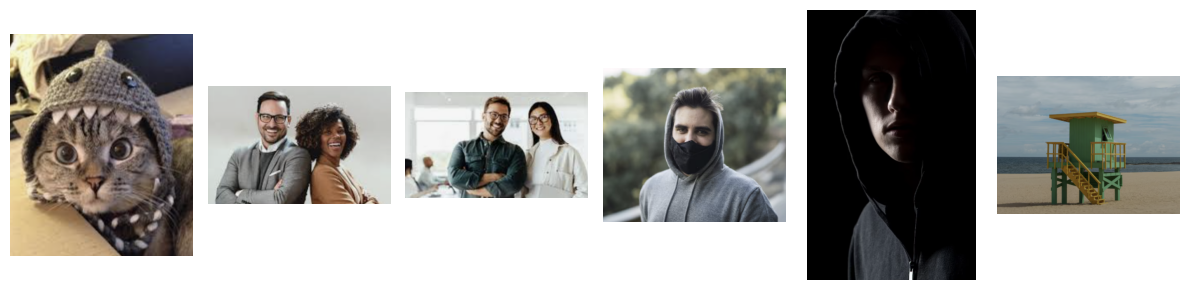

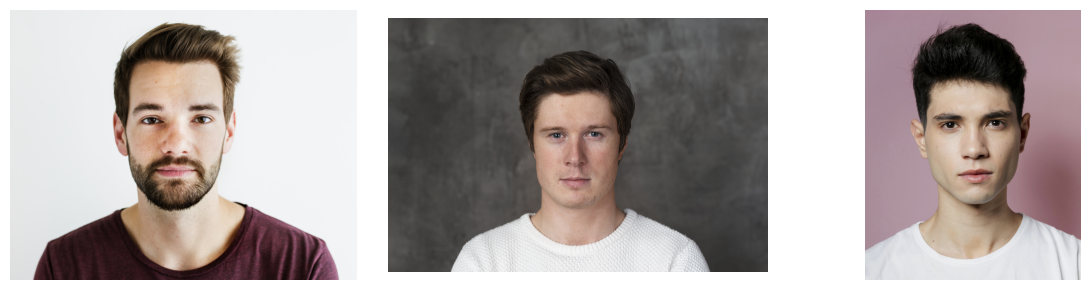

In [12]:
import torch
import torch.nn.functional as F
import numpy as np 

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt


db_embeddings = torch.load("data/faces/db_embeddings.pt")
new_embeddings = torch.load("data/faces/new_embeddings.pt")

file_path = 'data/faces/new_paths.npy'
new_paths = np.load(file_path)


def find_invalid_images(new_embeddings, db_embeddings, new_paths, threshold=0.5):
    # Нормализуем эмбеддинги
    db_embeddings = F.normalize(db_embeddings, p=2, dim=1)
    new_embeddings = F.normalize(new_embeddings, p=2, dim=1)

    # Вычисляем косинусное сходство между новыми изображениями и архивными
    similarities = cosine_similarity(new_embeddings.numpy(), db_embeddings.numpy())
    max_similarities = similarities.max(axis=1)

    # Определяем, какие изображения не соответствуют формату
    invalid_mask = max_similarities < threshold
    invalid_paths = new_paths[invalid_mask]

    return invalid_paths, max_similarities


def display_images(image_paths, figsize=(12, 3)):
    """
    Отображает изображения из списка путей в одну строку (горизонтально)
    """
    num_images = len(image_paths)

    fig, axes = plt.subplots(1, num_images, figsize=figsize)
    fig.subplots_adjust(wspace=0.2)

    # Отображаем изображения
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            img = Image.open(image_paths[i])
            ax.imshow(img)
            ax.axis('off')

    plt.tight_layout()
    plt.show()
   

invalid_images, similarities = find_invalid_images(new_embeddings, 
             db_embeddings, new_paths, threshold=0.68)

# Визуализируем фото, не прошедшие проверку
display_images(invalid_images)
# Визуализируем фото, прошедшие проверку
display_images(list(set(new_paths).difference(invalid_images))) 